# ClaimWise Insurance Prediction — 03. Exploratory Data Analysis

## 1. Objective

Explore the **preprocessed** ClaimWise dataset (`Dataset/05_preprocessed_final.csv`) and produce the
project's standard set of EDA figures.

The plotting code is not rewritten here: the existing project script
`Src/6_EDA_Analysis.py` is executed, which saves 30+ figures (target distribution, feature
histograms, boxplots, correlation heatmap, count plots, missing-value heatmap) into
`Outputs/EDA_Analysis_outputs/`. The key figures are then displayed inline and a few numeric
summaries are computed.

> `Src/Correlation_Matrix_heatmap_boxplots_M1.py` is an existing supplementary module that writes
> the same correlation/boxplot views into `Outputs/Boxplots_correlation/`. It is kept unchanged and
> is not re-run here to avoid duplicating outputs.

## 2. Import Libraries

In [1]:
%matplotlib inline
import runpy

import pandas as pd
from IPython.display import Image

In [2]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """Walk upwards from the notebook folder until the ClaimWise project is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "Dataset").is_dir() and (candidate / "Src").is_dir():
            return candidate
    raise FileNotFoundError(f"ClaimWise project root not found above: {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / "Dataset"
SRC_DIR = PROJECT_ROOT / "Src"
MODELS_DIR = PROJECT_ROOT / "Models"
OUTPUTS_DIR = PROJECT_ROOT / "Outputs"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root  :", PROJECT_ROOT)
print("Dataset folder:", DATASET_DIR)
print("Src folder    :", SRC_DIR)

Project root  : /Users/padaltiruvinayak/Desktop/Credit ML
Dataset folder: /Users/padaltiruvinayak/Desktop/Credit ML/Dataset
Src folder    : /Users/padaltiruvinayak/Desktop/Credit ML/Src


## 3. Load the Preprocessed Dataset

In [3]:
PREPROCESSED_PATH = DATASET_DIR / "05_preprocessed_final.csv"

if not PREPROCESSED_PATH.exists():
    raise FileNotFoundError(
        f"Preprocessed dataset not found: {PREPROCESSED_PATH}. "
        "Run 02_ClaimWise_Data_Preprocessing.ipynb first."
    )

df = pd.read_csv(PREPROCESSED_PATH)

print("Loaded:", PREPROCESSED_PATH.name)
print("Shape :", df.shape)
print("Missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Target column : loss")
print("Numeric columns:", int(df.select_dtypes(include="number").shape[1]))
display(df.head())

Loaded: 05_preprocessed_final.csv
Shape : (50000, 131)
Missing values: 0
Duplicate rows: 0
Target column : loss
Numeric columns: 131


,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,cat10,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,0,0,0,0,1,1,0,0,0,0,...,-1.322232,-1.219908,-1.047061,-0.570672,-1.015993,-1.190151,-1.208187,-0.916695,1.034612,611.51
1,1,0,0,0,1,0,0,0,0,0,...,0.769098,-0.154637,0.679107,1.520458,0.065873,0.888645,0.828071,1.076076,0.818991,313.24
2,0,0,0,1,0,1,0,0,0,0,...,1.003200,0.297153,-0.660682,-0.570672,1.295804,0.790501,0.729979,1.137809,-0.600177,550.11
3,0,1,0,0,0,0,0,0,1,0,...,1.738459,1.155561,1.002005,1.281494,1.612809,1.496789,1.443898,1.621798,-0.618862,586.83
4,1,0,0,0,1,1,0,0,0,0,...,0.584964,1.688438,-0.521584,-0.504801,0.006098,1.029610,0.969532,0.521780,-0.684254,586.61


## 4. Run the Existing EDA Script

All figures below are generated from the real preprocessed dataset by the project's own EDA module
and saved to `Outputs/EDA_Analysis_outputs/`.

In [4]:
# Execute the project's existing EDA module (it saves every figure to Outputs/EDA_Analysis_outputs/).
eda_namespace = runpy.run_path(str(SRC_DIR / "6_EDA_Analysis.py"))
print("EDA script executed:", eda_namespace["__file__"])


Preprocessed dataset file found:
/Users/padaltiruvinayak/Desktop/Credit ML/Dataset/05_preprocessed_final.csv


CLAIMWISE INSURANCE PREDICTION - EDA ANALYSIS
First Five Records:
   cat1  cat2  cat3  cat4  cat5  cat6  cat7  cat8  cat9  cat10  ...     cont6  \
0     0     0     0     0     1     1     0     0     0      0  ... -1.322232   
1     1     0     0     0     1     0     0     0     0      0  ...  0.769098   
2     0     0     0     1     0     1     0     0     0      0  ...  1.003200   
3     0     1     0     0     0     0     0     0     1      0  ...  1.738459   
4     1     0     0     0     1     1     0     0     0      0  ...  0.584964   

      cont7     cont8     cont9    cont10    cont11    cont12    cont13  \
0 -1.219908 -1.047061 -0.570672 -1.015993 -1.190151 -1.208187 -0.916695   
1 -0.154637  0.679107  1.520458  0.065873  0.888645  0.828071  1.076076   
2  0.297153 -0.660682 -0.570672  1.295804  0.790501  0.729979  1.137809   
3  1.155561  1.002005  1.281494  1.612809  1.496789  1.443898  1.621798   
4  1.688438 -0.521584 -0.504801  0.006098  1.029610  0.969532  0.521780 


Generating Feature Distribution Plots (02_feature_distribution_*.png)...



Generating Individual Boxplot PNG Images (03_boxplot_*.png)...



Generating Correlation Heatmap (04_correlation_heatmap.png)...



Generating Categorical Feature Count Plots (05_countplot_*.png)...



Generating Missing Values Heatmap (06_missing_values_heatmap.png)...



EDA COMPLETED SUCCESSFULLY
All figures are saved in: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/EDA_Analysis_outputs
EDA script executed: /Users/padaltiruvinayak/Desktop/Credit ML/Src/6_EDA_Analysis.py


## 5. Key Figures

01_target_distribution.png


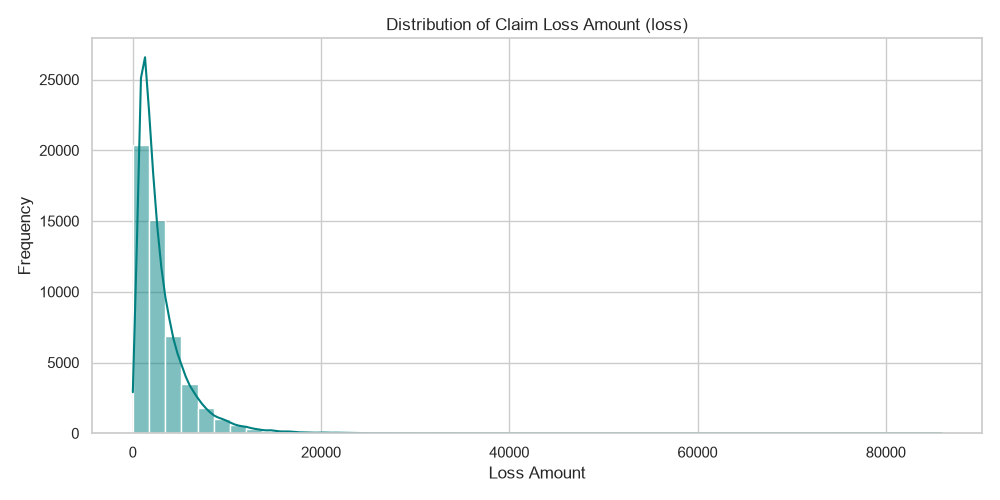

04_correlation_heatmap.png


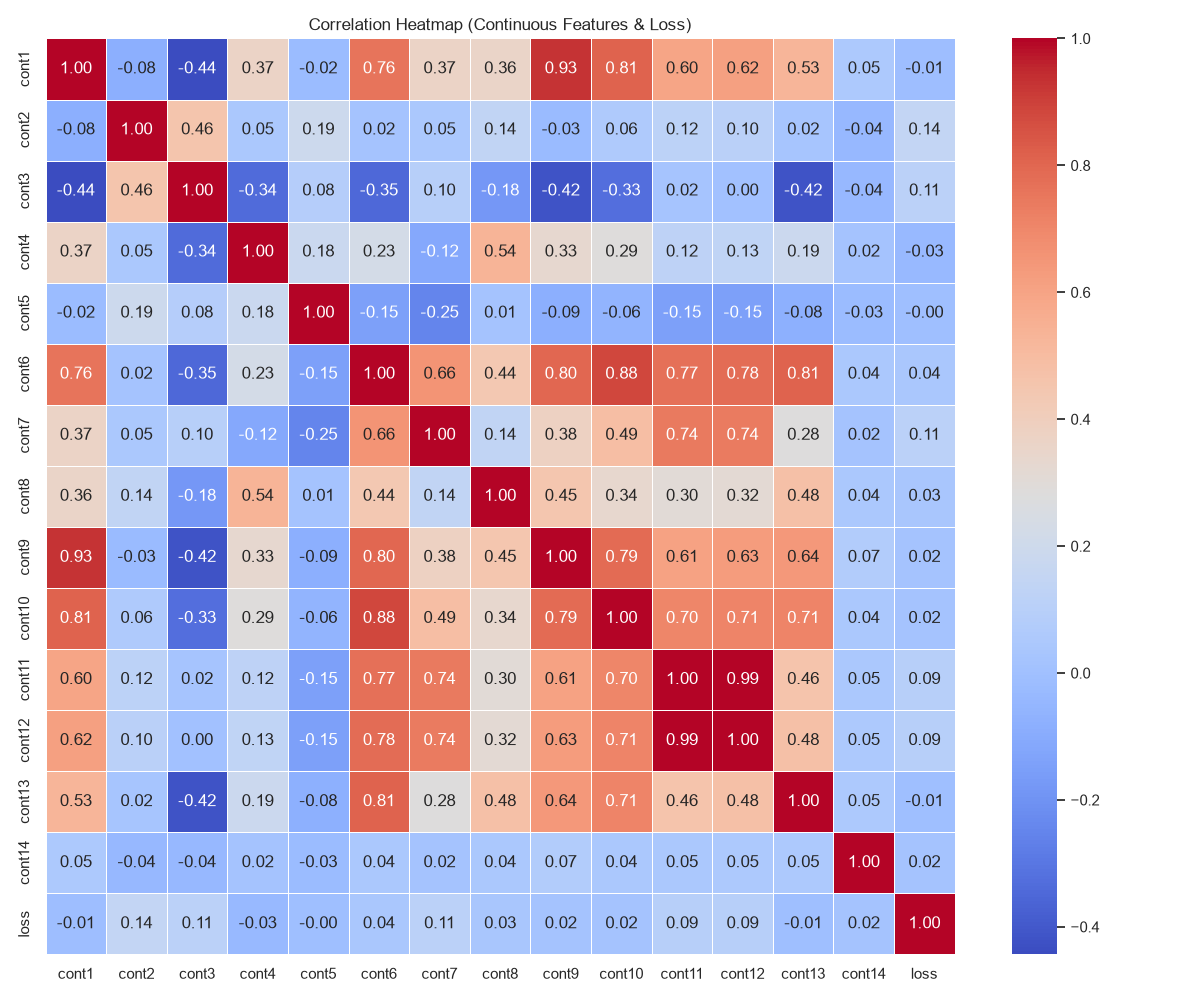

06_missing_values_heatmap.png


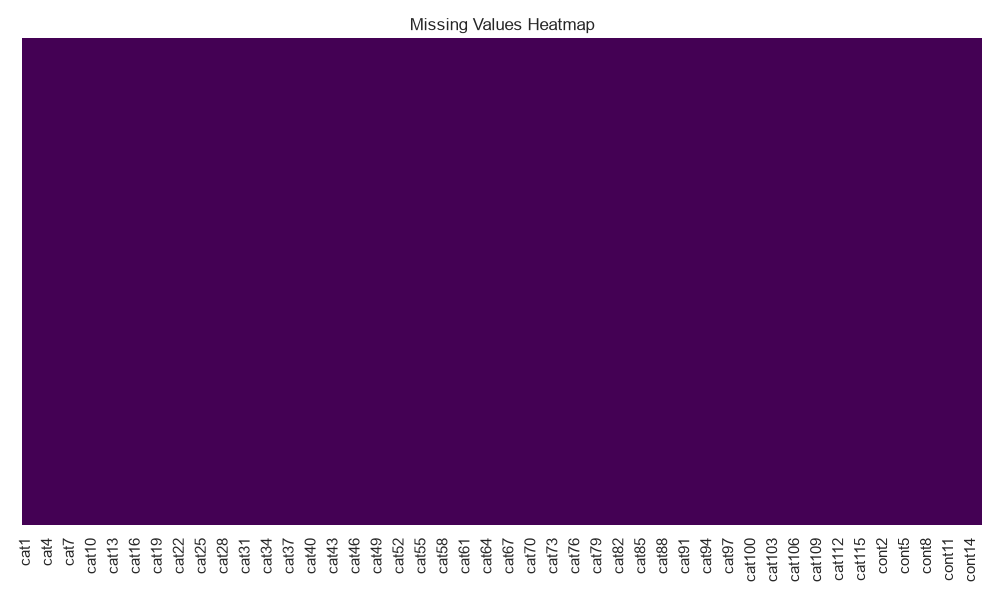

02_feature_distribution_cont1.png


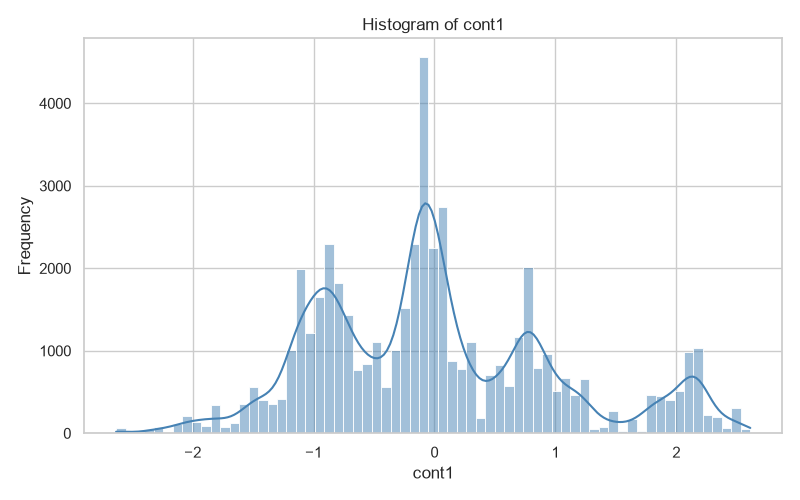

05_countplot_cat1.png


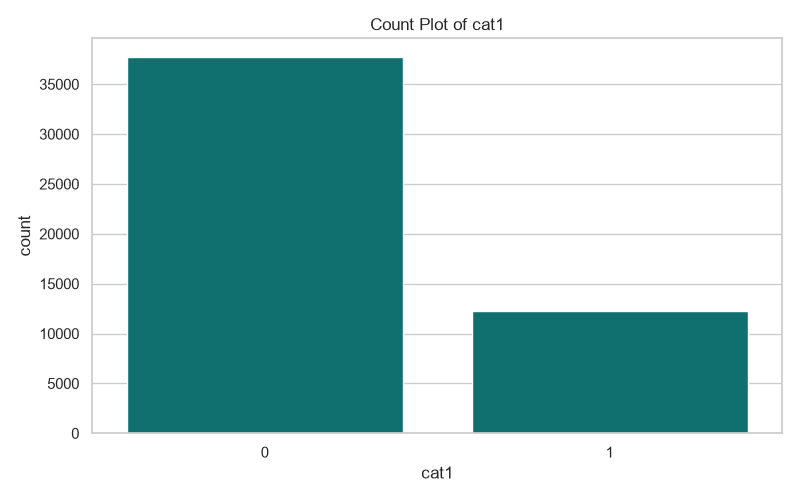

In [5]:
EDA_DIR = OUTPUTS_DIR / "EDA_Analysis_outputs"

for figure_name in [
    "01_target_distribution.png",
    "04_correlation_heatmap.png",
    "06_missing_values_heatmap.png",
    "02_feature_distribution_cont1.png",
    "05_countplot_cat1.png",
]:
    print(figure_name)
    display(Image(filename=str(EDA_DIR / figure_name)))

## 6. Numeric Summary — Relationship with the Target

Correlation of every input feature with `loss`, computed from the actual dataset.

In [6]:
correlation_with_loss = df.corr(numeric_only=True)["loss"].drop("loss")
correlation_with_loss = correlation_with_loss.sort_values(ascending=False)

print("Top 10 features most correlated with 'loss':")
display(correlation_with_loss.head(10).to_frame("correlation_with_loss"))

print("10 features least correlated with 'loss':")
display(correlation_with_loss.tail(10).to_frame("correlation_with_loss"))

corr_path = EDA_DIR / "claimwise_correlation_with_loss.csv"
correlation_with_loss.to_frame("correlation_with_loss").to_csv(corr_path)
print("Saved all", len(correlation_with_loss), "correlations to:", corr_path)

Top 10 features most correlated with 'loss':


,correlation_with_loss
cat79,0.442056
cat87,0.342313
cat101,0.342173
cat12,0.308643
cat57,0.308096
cat10,0.279111
cat7,0.267367
cat89,0.251730
cat2,0.232344
cat11,0.225279


10 features least correlated with 'loss':


,correlation_with_loss
cat95,-0.041781
cat106,-0.061793
cat75,-0.071219
cat82,-0.104564
cat50,-0.108041
cat6,-0.114441
cat73,-0.156202
cat1,-0.221716
cat81,-0.263482
cat80,-0.473166


Saved all 130 correlations to: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/EDA_Analysis_outputs/claimwise_correlation_with_loss.csv


In [7]:
continuous_columns = [col for col in df.columns if col.startswith("cont")]
target_summary = df["loss"].describe().to_frame("loss")
display(target_summary)

print("Continuous features:", len(continuous_columns), continuous_columns)
print("Highest absolute correlation with loss:",
      correlation_with_loss.abs().idxmax(),
      round(float(correlation_with_loss.abs().max()), 4))

,loss
count,50000.000000
mean,3035.011651
std,2899.704669
min,10.000000
25%,1204.520000
50%,2115.465000
75%,3863.720000
max,85923.560000


Continuous features: 14 ['cont1', 'cont2', 'cont3', 'cont4', 'cont5', 'cont6', 'cont7', 'cont8', 'cont9', 'cont10', 'cont11', 'cont12', 'cont13', 'cont14']
Highest absolute correlation with loss: cat80 0.4732


## 7. Conclusion

All EDA figures were regenerated by the project's own module (`Src/6_EDA_Analysis.py`) from the
real preprocessed dataset and written to `Outputs/EDA_Analysis_outputs/`. Verified in this run:

- data: 50,000 rows x 131 columns, 0 missing values, 0 duplicate rows, all numeric
- target `loss`: mean 3,035.01, std 2,899.70, min 10.00, max 85,923.56 (right-skewed)
- strongest correlations with `loss`: `cat80` (r = -0.4732), `cat79` (r = +0.4421),
  `cat87` (r = +0.3423), `cat101` (r = +0.3422)
- all 130 feature correlations saved to
  `Outputs/EDA_Analysis_outputs/claimwise_correlation_with_loss.csv`

Next: `04_ClaimWise_Linear_Regression.ipynb`.